# Convolutional Neural Network

In [ ]:
##########
# Library Imports
## Not all libraries are imported in this first cell as a way to spare some computing power
##########

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from PIL import Image
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [ ]:
# Load CSV file with image names, health status and train/val/test grouping (stratified split)
bee_data = pd.read_csv("../data/processed/processed_bee_data_20260330_151740.csv", sep=';')

# Top 5 lines
display(bee_data.head())

# Information on simple shape of dataset imported
print(bee_data.shape)

# Further information on dataset
display(bee_data.describe(include="all").T)

,file,health,split_group
0,040_070.png,unhealthy,train
1,040_328.png,unhealthy,train
2,010_441.png,healthy,train
3,015_770.png,healthy,train
4,038_149.png,unhealthy,train


(5172, 3)


,count,unique,top,freq
file,5172,5172,040_070.png,1
health,5172,2,healthy,3384
split_group,5172,3,train,4137


In [ ]:
# Necessary features (X) and target (y)
x = bee_data[['file']].copy()
y = bee_data['health'].copy()

# Use the predefined split groups from processed_bee_data
split_col = bee_data['split_group'].str.lower()

x_train = x[split_col == 'train']
y_train = y[split_col == 'train']

x_val = x[split_col == 'val']
y_val = y[split_col == 'val']

x_test = x[split_col == 'test']
y_test = y[split_col == 'test']

# Shape,  # rows, # columns for each split
print("Training")
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print("\nValidation")
print(f"x_val shape: {x_val.shape}")
print(f"y_val shape: {y_val.shape}")
print("\nTesting")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}\n")

# Number of unique classes
num_classes_train = len(np.unique(y_train))
num_classes_val = len(np.unique(y_val))
num_classes_test = len(np.unique(y_test))

print(f"Number of classes in training set: {num_classes_train}")
print(f"Number of classes in validation set: {num_classes_val}")
print(f"Number of classes in test set: {num_classes_test}\n")

# Quick check for train-test-val counts
print(bee_data[['file', 'split_group']].head(10), "\n")
print(bee_data['split_group'].value_counts())

Training
x_train shape: (4137, 1)
y_train shape: (4137,)

Validation
x_val shape: (517, 1)
y_val shape: (517,)

Testing
x_test shape: (518, 1)
y_test shape: (518,)

Number of classes in training set: 2
Number of classes in validation set: 2
Number of classes in test set: 2

           file split_group
0   040_070.png       train
1   040_328.png       train
2   010_441.png       train
3   015_770.png       train
4   038_149.png       train
5   032_361.png       train
6  019_1354.png       train
7  015_1260.png       train
8   032_547.png       train
9   040_363.png       train 

split_group
train    4137
test      518
val       517
Name: count, dtype: int64


# 6 Random Images
The below code cell is showing 3-3 random images of type "healthy" and "unhealthy.

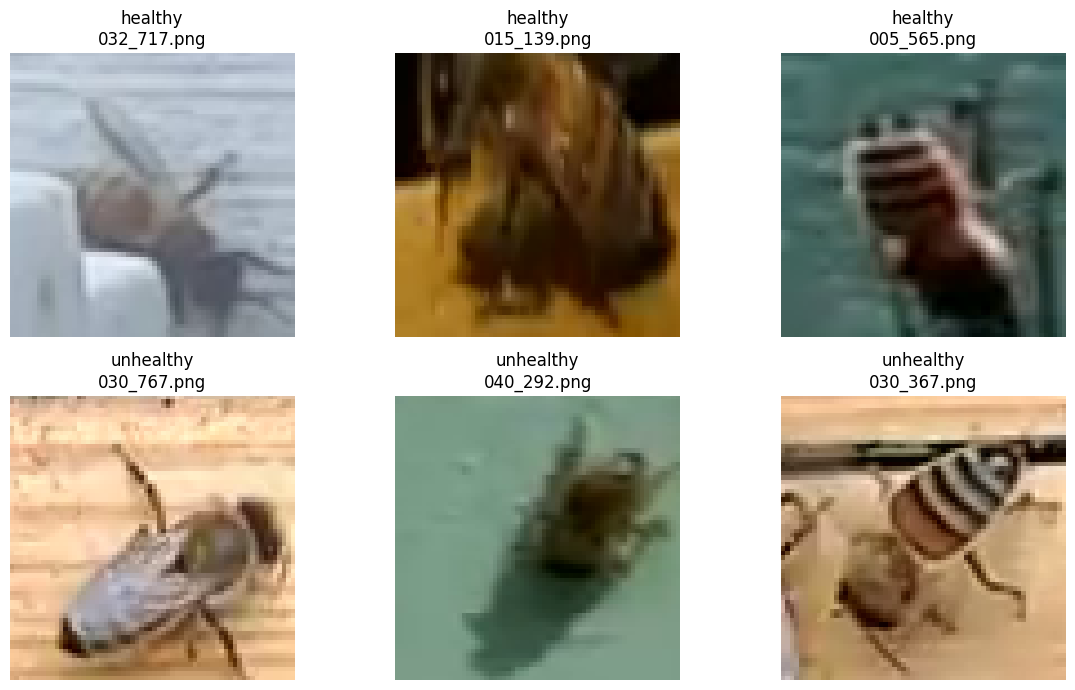

In [ ]:
class_names = ["healthy", "unhealthy"]

# Convert labels to a NumPy array for easier indexing
y_train_labels = y_train.astype(str).str.lower().to_numpy()

# Indices by class
healthy_indices = np.where(y_train_labels == "healthy")[0]
unhealthy_indices = np.where(y_train_labels == "unhealthy")[0]

# Load and resize only selected images for faster preview
def load_preview_image(filename, preview_size=(64, 64)):
    img_path = os.path.join("../data/bee_imgs", filename)
    with Image.open(img_path) as img:
        img = img.convert("RGB")
        img = img.resize(preview_size)
        return np.array(img)

# Sample 3 images from each class
n_per_class = 3
healthy_pick = np.random.choice(
    healthy_indices,
    size=n_per_class,
    replace=len(healthy_indices) < n_per_class
)
unhealthy_pick = np.random.choice(
    unhealthy_indices,
    size=n_per_class,
    replace=len(unhealthy_indices) < n_per_class
)

# Combine image picks so first row is healthy, second row is unhealthy
picked_indices = np.concatenate([healthy_pick, unhealthy_pick])

plt.figure(figsize=(12, 7))
for i, index in enumerate(picked_indices):
    plt.subplot(2, 3, i + 1)

    filename = x_train.iloc[index, 0]
    label = y_train.iloc[index]
    preview_img = load_preview_image(filename)
    plt.imshow(preview_img)

    plt.title(f"{label}\n{filename}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Train samples: 4137
Validation samples: 517
Test samples: 518
Image size: 128x128, batch size: 32


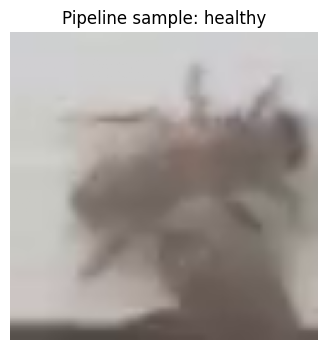

In [ ]:
# Input pipeline for more efficient image loading:
# 1. Load
# 2. Resize (128x128)
# 3. Normalize pixel values 0-255
# 4. Batch (tensorflow)
# 5. Load and Prefetch (tensorflow)

import tensorflow as tf

IMG_SIZE = 128
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE # dynamic runtime tuning (Tensorflow tf.data documentation)

# Encode labels once: one-hot conversion happens inside pipeline
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train.astype(str))
y_val_encoded = label_encoder.transform(y_val.astype(str))
y_test_encoded = label_encoder.transform(y_test.astype(str))
num_classes = len(label_encoder.classes_)

# Get file paths
def make_paths(file_series):
    return file_series.astype(str).apply(
        lambda name: os.path.join("../data/bee_imgs", name)
    ).to_numpy()

train_paths = make_paths(x_train.iloc[:, 0])
val_paths = make_paths(x_val.iloc[:, 0])
test_paths = make_paths(x_test.iloc[:, 0])

# Load and preprocess pipeline
def load_and_preprocess(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False) # decode color channels
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE]) # resize
    image = tf.cast(image, tf.float32) / 255.0 # normalization
    image.set_shape((IMG_SIZE, IMG_SIZE, 3)) # shape of vector
    label = tf.one_hot(label, depth=num_classes) # one-hot encoding
    return image, label

# Create dataset of images, batch and prefetch loading
# strong shuffling: reduce bias from image order (same health class images next to each other)
# batch size = 32
def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, y_train_encoded, training=True)
val_ds = make_dataset(val_paths, y_val_encoded, training=False)
test_ds = make_dataset(test_paths, y_test_encoded, training=False)

print(f"Train samples: {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")
print(f"Test samples: {len(test_paths)}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}, batch size: {BATCH_SIZE}")

# Showing one preprocessed sample image
for sample_images, sample_labels in train_ds.take(1):
    sample_image = sample_images[0].numpy()
    sample_label_idx = int(tf.argmax(sample_labels[0]).numpy())
    sample_label_name = label_encoder.inverse_transform([sample_label_idx])[0]

plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.title(f"Pipeline sample: {sample_label_name}")
plt.axis("off")
plt.show()

In [ ]:
# Quick check for the label setup from the TensorFlow pipeline
# The labels are already integer-encoded and converted to one-hot vectors inside the dataset
print(f"Classes: {list(label_encoder.classes_)}")
print(f"Number of classes: {num_classes}")

# Count how many batches were created for each dataset split
# This helps estimate how many steps the model sees during training and evaluation
train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches = tf.data.experimental.cardinality(val_ds).numpy()
test_batches = tf.data.experimental.cardinality(test_ds).numpy()

print(f"Train batches: {train_batches}")
print(f"Validation batches: {val_batches}")
print(f"Test batches: {test_batches}")

Classes: ['healthy', 'unhealthy']
Number of classes: 2
Train batches: 130
Validation batches: 17
Test batches: 17


As the laptop that was used for the project has an integrated GPU, Tensorflow doesn't detect a separate GPU unit.

In [7]:
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
# GPU list is empty, staying on CPU

TensorFlow: 2.20.0
GPUs: []


## Simple CNN Architecture
- Input images are resized to 128 x 128 pixels before training.
- The model uses two convolutional layers with max-pooling to extract visual features.
- After flattening, a dense layer with 64 neurons learns higher-level patterns.
- A dropout layer (0.30) is included to reduce overfitting.
- The output layer uses softmax activation to predict the image class.
- This architecture is intentionally simple so it can be used as a baseline for comparison.

In [ ]:
from tensorflow import keras 
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Construction of CNN model
# ReLu activation and MaxPooling
model_basic = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2, 2),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(64, activation='relu', name='feature_dense_64'),
    Dropout(0.30),
    Dense(num_classes, activation='softmax')
], name='simple_cnn_v2')

# Compile the model with Adam optimization and categorical cross-entropy loss
# Accuracy is used as the main training metric for quick comparison
# Final model evaluation includes Recall and F1-Score as more important evaluation metrics
model_basic.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("=" * 50)
print("MODEL 1: Simple CNN")
print("=" * 50)
model_basic.summary()

# This architecture is kept simple on purpose so it can be compared more easily with the other models.

MODEL 1: Simple CNN


c:\Users\palag\Documents\Egyetem\THESIS\beeproject-cnn\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "simple_cnn_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_dense_64 (Dense)        │ (None, 64)             │     1,843,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,848,482 (7.05 MB)

 Trainable params: 1,848,482 (7.05 MB)

 Non-trainable params: 0 (0.00 B)

# CNN Training

- 30 epochs max
- EarlyStopping starting from epoch 5
- Model is validated on separate validation set

The epoch number is quite low (30), but the model always seemed to converge between epoch 8 and 20, with the best results usually occurring between epoch 8-13.
The low epoch number and basic model structure might have influenced the good performance of the CNN. When the model is simple, it's easier to catch only the background colors and patterns. This makes it easy for the model to focus on the background structure instead of the bees. This is further explained in the Bachelor Thesis' findings.

In [ ]:
# Train the simple CNN model and monitor validation performance

print("\nTraining the simple CNN model...")

# Early stopping is used to reduce overfitting
# Training stops if the validation loss does not improve for 5 epochs
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        mode='min',
        start_from_epoch=5,
        restore_best_weights=True,
        verbose=1
    )
]

# Measure total training time for later comparison with other models
training_start_time = time.perf_counter()

history = model_basic.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)
training_end_time = time.perf_counter()
training_time_for_model = training_end_time - training_start_time

# Evaluate the trained model on the separate test set
print("\nEvaluating on test set...")
test_loss, test_accuracy = model_basic.evaluate(test_ds)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Report the epoch with the lowest validation loss as the best training result
best_epoch = int(np.argmin(history.history['val_loss'])) + 1
best_val_loss = history.history['val_loss'][best_epoch - 1]
print(f"Best epoch by val_loss: {best_epoch}")
print(f"val_loss of best epoch: {best_val_loss:.4f}")
print(f"Training time for model: {training_time_for_model:.2f} seconds")


Training the simple CNN model...
Epoch 1/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9944 - loss: 0.0156 - val_accuracy: 0.9323 - val_loss: 0.2742
Epoch 2/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9923 - loss: 0.0220 - val_accuracy: 0.9826 - val_loss: 0.0587
Epoch 3/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9964 - loss: 0.0101 - val_accuracy: 0.9710 - val_loss: 0.1103
Epoch 4/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9988 - loss: 0.0040 - val_accuracy: 0.9729 - val_loss: 0.1119
Epoch 5/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9995 - loss: 0.0023 - val_accuracy: 0.9807 - val_loss: 0.0697
Epoch 6/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9952 - loss: 0.0139 - val_accuracy: 0.9671 - val_loss: 0.1065
Epoch 7/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9952 - loss: 0.0159 - val_accuracy: 0.9826 - val_loss: 0.0554
Epoch 8/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy

In [ ]:
## DISCLAIMER: Only run this cell if you want to save the model, the result is a bigger file
# Save full trained model (architecture + weights + optimizer state)

model_basic.save("best_cnn.keras")
print("Saved:", os.path.abspath("best_cnn.keras"))

Saved: c:\Users\palag\Documents\Egyetem\THESIS\beeproject-cnn\models\best_cnn.keras


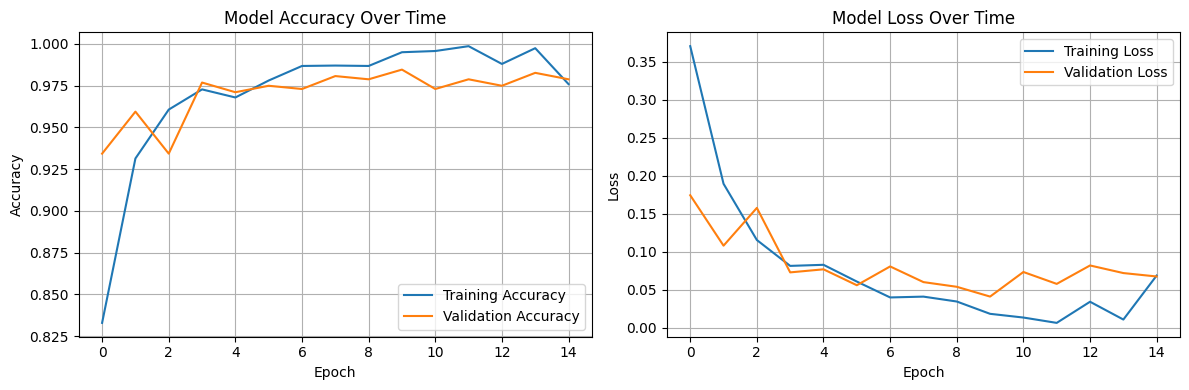

In [ ]:
# Plot the Training and Validation performance across epochs
plt.figure(figsize=(12, 4))

# Accuracy plot during training
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Time')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot to help check whether the model improved and whether overfitting appeared
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Final Model Evaluation

First we use the trained model for predictions on the test set, then to evaluate performance we look at:
- numeric values of Accuracy, Recall, Precision, F1-Score, ROC-AUC Score
- Confusion Matrix
- ROC-AUC Curve

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Prediction time for model: 0.26 seconds
Test set classification report:
              precision    recall  f1-score   support

     healthy       0.97      1.00      0.98       339
   unhealthy       0.99      0.94      0.97       179

    accuracy                           0.98       518
   macro avg       0.98      0.97      0.97       518
weighted avg       0.98      0.98      0.98       518

Summary metrics (positive class = unhealthy):
Accuracy:  0.9768
Precision: 0.9941
Recall:    0.9385
F1-score:  0.9655
ROC AUC:   0.9988


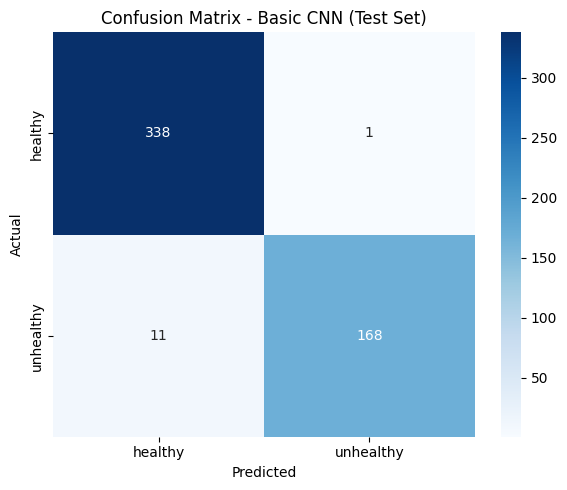

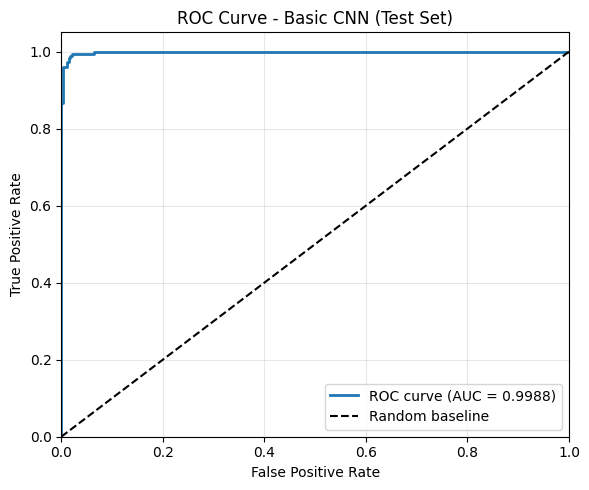

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
 )

# Final evaluation of the CNN on the held out test set
# Prediction time is also measured so runtime can be compared with other models
prediction_start_time = time.perf_counter()

y_pred_proba = model_basic.predict(test_ds)
y_pred_classes = np.argmax(y_pred_proba, axis=1)

prediction_end_time = time.perf_counter()
prediction_time_for_model = prediction_end_time - prediction_start_time

print(f"Prediction time for model: {prediction_time_for_model:.2f} seconds")

# Convert predicted class indices back to the original class names
y_pred_labels = label_encoder.inverse_transform(y_pred_classes)
y_test_labels = y_test.astype(str).to_numpy()

# Calculate the main classification metrics on the test set
acc = accuracy_score(y_test_labels, y_pred_labels)
prec = precision_score(y_test_labels, y_pred_labels, pos_label="unhealthy")
rec = recall_score(y_test_labels, y_pred_labels, pos_label="unhealthy")
f1 = f1_score(y_test_labels, y_pred_labels, pos_label="unhealthy")

# ROC-AUC is calculated by treating the label "unhealthy" as the positive class
positive_label = "unhealthy"
positive_class_index = int(np.where(label_encoder.classes_ == positive_label)[0][0])
y_test_binary = (y_test_labels == positive_label).astype(int)
y_pred_positive_proba = y_pred_proba[:, positive_class_index]
roc_auc = roc_auc_score(y_test_binary, y_pred_positive_proba)
fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred_positive_proba)

print("Test set classification report:")
print(classification_report(y_test_labels, y_pred_labels))

print("Summary metrics (positive class = unhealthy):")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")

# Confusion matrix shows how many healthy and unhealthy images were classified correctly/incorrectly
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=["healthy", "unhealthy"])
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["healthy", "unhealthy"],
    yticklabels=["healthy", "unhealthy"],
)
plt.title("Confusion Matrix - Basic CNN (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# The ROC curve shows how well the model separates the two classes at different thresholds
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Basic CNN (Test Set)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()